# Pipeline Preditivo da MecâniQA

Entrega do encontro: integrar tratamento de valores nulos, padronização e modelo preditivo em um único `Pipeline` do Scikit-Learn. A divisão entre treino e teste respeita a ordem temporal dos dados para evitar vazamento de informações futuras.

## 1. Importação das bibliotecas

In [26]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## 2. Carregamento e organização temporal

A série principal continua sendo `Trocas_Oleo`, conforme a decisão já adotada pela equipe.

In [27]:
data_path = next((
    path for path in [
        Path("data/mecaniqa_dataset.xlsx"),
        Path("../data/mecaniqa_dataset.xlsx"),
    ]
    if path.exists()
), None)

if data_path is None:
    raise FileNotFoundError(
        "Dataset não encontrado. Abra o projeto pela pasta mecaniQA-salvador."
    )

df = pd.read_excel(data_path)
df["Data"] = pd.to_datetime(df["Data"])
df = df.sort_values("Data").set_index("Data")

serie = df["Trocas_Oleo"].resample("D").asfreq()
serie.head()

Data
2024-01-01    11.0
2024-01-02     9.0
2024-01-03    12.0
2024-01-04    15.0
2024-01-05    25.0
Freq: D, Name: Trocas_Oleo, dtype: float64

Todas as variáveis de histórico usam `shift(1)`: a previsão de um dia enxerga somente informações disponíveis até o dia anterior. Como as janelas precisam de um período inicial de aquecimento e a série pode conter dias sem alvo, as linhas sem histórico completo são descartadas após a criação das features. Assim, o dataset permanente usado pelo modelo não contém nulos nem utiliza preenchimento com informações futuras.

In [28]:
df = pd.DataFrame(index=serie.index)
df["alvo"] = serie
df["lag_1"] = df["alvo"].shift(1)
df["lag_7"] = df["alvo"].shift(7)
df["rolling_7"] = df["alvo"].shift(1).rolling(window=7, min_periods=7).mean()
df["rolling_30"] = df["alvo"].shift(1).rolling(window=30, min_periods=30).mean()
df["dia_semana"] = df.index.dayofweek
df["mes"] = df.index.month

# O descarte do aquecimento evita preencher lags com informacao futura.
colunas_temporais = ["lag_1", "lag_7", "rolling_7", "rolling_30"]
df = df.dropna(subset=colunas_temporais + ["alvo"])

# O DataFrame usado pelo modelo ja contem somente linhas completas.
dados_modelo = df.copy()
X = dados_modelo.drop(columns="alvo")
y = dados_modelo["alvo"]

print(f"Linhas removidas pelo aquecimento temporal: {len(serie) - len(df)}")
print(f"Nulos nas features temporais: {df[colunas_temporais].isna().sum().sum()}")
df.head(15)

Linhas removidas pelo aquecimento temporal: 66
Nulos nas features temporais: 0


,alvo,lag_1,lag_7,rolling_7,rolling_30,dia_semana,mes
Data,,,,,,,
2024-01-31,14.0,14.0,10.0,19.571429,17.900000,2,1
2024-02-01,21.0,14.0,13.0,20.142857,18.000000,3,2
2024-02-02,31.0,21.0,30.0,21.285714,18.400000,4,2
2024-02-03,28.0,31.0,26.0,21.428571,19.033333,5,2
2024-02-04,34.0,28.0,31.0,21.714286,19.466667,6,2
2024-02-05,13.0,34.0,13.0,22.142857,19.766667,0,2
2024-02-06,17.0,13.0,14.0,22.142857,19.366667,1,2
2024-02-07,11.0,17.0,14.0,22.571429,18.900000,2,2
2024-02-08,13.0,11.0,21.0,22.142857,18.833333,3,2


## 4. Separação cronológica entre treino e teste

Os 20% finais da série ficam reservados para teste. Não há embaralhamento, pois isso misturaria passado e futuro.

In [29]:
ponto_corte = int(len(X) * 0.80)
X_train, X_test = X.iloc[:ponto_corte], X.iloc[ponto_corte:]
y_train, y_test = y.iloc[:ponto_corte], y.iloc[ponto_corte:]

print(f"Treino: {X_train.index.min().date()} a {X_train.index.max().date()} ({len(X_train)} dias)")
print(f"Teste:  {X_test.index.min().date()} a {X_test.index.max().date()} ({len(X_test)} dias)")

Treino: 2024-01-31 a 2025-08-20 (532 dias)
Teste:  2025-08-21 a 2025-12-31 (133 dias)


## 5. Ajuste do hiperparâmetro do modelo

A regressão Ridge foi adotada porque trabalha bem com variáveis padronizadas e controla a complexidade por meio do hiperparâmetro `alpha`. A busca usa `TimeSeriesSplit`, preservando a ordem temporal em cada validação.

In [30]:
pipeline_busca = Pipeline(steps=[
    ("imputacao", SimpleImputer(strategy="median")),
    ("padronizacao", StandardScaler()),
    ("modelo", Ridge())
])

busca = GridSearchCV(
    estimator=pipeline_busca,
    param_grid={"modelo__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    scoring="neg_mean_absolute_error",
    cv=TimeSeriesSplit(n_splits=5),
)
busca.fit(X_train, y_train)

melhor_alpha = busca.best_params_["modelo__alpha"]
print(f"Melhor alpha: {melhor_alpha}")

Melhor alpha: 10.0


## 6. Pipeline final da equipe

A ordem segue o brainstorm: **preencher nulos → padronizar → aplicar o modelo preditivo tunado**. O `fit` é executado em uma única linha, como solicitado no guia.

In [31]:
pipeline = Pipeline(steps=[
    ("imputacao", SimpleImputer(strategy="median")),
    ("padronizacao", StandardScaler()),
    ("modelo", Ridge(alpha=melhor_alpha))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputacao', ...), ('padronizacao', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['lag_1','lag_7','rolling_7','rolling_30','dia_semana','mes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",N

## 7. Avaliação no período de teste

In [32]:
previsoes = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, previsoes)
rmse = np.sqrt(mean_squared_error(y_test, previsoes))
r2 = r2_score(y_test, previsoes)

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

MAE:  4.115
RMSE: 4.983
R²:   0.672


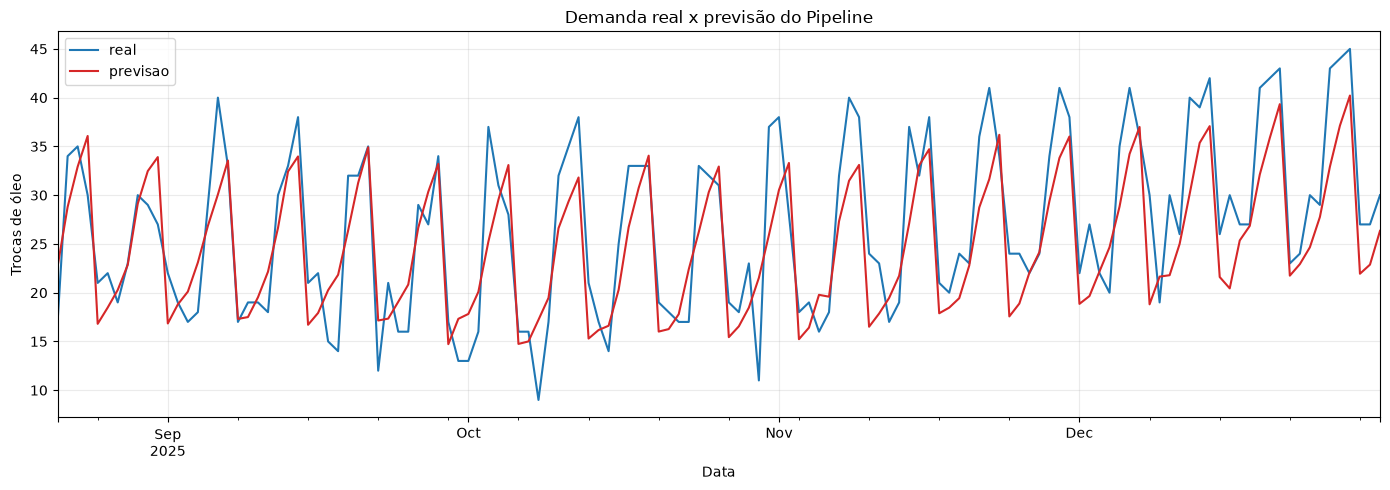

In [33]:
resultado = pd.DataFrame({
    "real": y_test,
    "previsao": previsoes,
}, index=y_test.index)

ax = resultado.plot(figsize=(14, 5), color=["#1f77b4", "#d62728"])
ax.set_title("Demanda real x previsão do Pipeline")
ax.set_xlabel("Data")
ax.set_ylabel("Trocas de óleo")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 8. Verificação contra vazamento de dados

Após o treinamento, o `SimpleImputer` e o `StandardScaler` guardam somente as estatísticas calculadas em `X_train`. Ao chamar `pipeline.predict(X_test)` ou prever dados novos, o pipeline executa apenas `transform` nesses dados; ele não recalcula mediana, média ou escala.